# MNIST – egna handskrivna bilder från mobilen

Den här notebooken bygger vidare på MNIST-exemplet och fokuserar på den centrala delen i uppgiften: preprocessing av verkliga bilder innan de skickas till en modell som tränats på MNIST.

Vi använder Extra Trees som klassisk ML-modell och använder samma preprocessing i notebooken och i Streamlit-applikationen.

In [33]:
# %pip install opencv-python

In [34]:
import os
import json
import joblib
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from preprocessing import preprocess_phone_digit
import time

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report




## 1. Ladda MNIST

Extra Trees är en trädmodell och behöver inte `StandardScaler`. Vi normaliserar i stället pixelvärdena till intervallet 0–1, vilket också gör samma representation enkel att använda för mobilbilder.

In [35]:
mnist = fetch_openml(
    'mnist_784',
    version=1,
    cache=True,
    as_frame=False
)

X = mnist["data"][:20000]
y = mnist["target"][:20000].astype(np.uint8)

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (20000, 784)
y shape: (20000,)


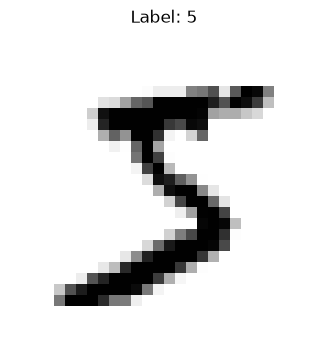

In [36]:
some_digit = X[0]

some_digit_image = some_digit.reshape(28, 28)

plt.figure(figsize=(4, 4))
plt.imshow(some_digit_image, cmap=plt.cm.binary)
plt.axis("off")
plt.title(f"Label: {y[0]}")
plt.show()

In [37]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.15,
    random_state=42,
    stratify=y_train_val
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (13600, 784)
Validation: (2400, 784)
Test: (4000, 784)


In [38]:
X_train = X_train.astype("float32") / 255.0
X_val = X_val.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [39]:

def augment_digit(flat_image, rng):
    """Return one photo-like variation of a flat 784 MNIST image (0-1 floats)."""
    image = (flat_image.reshape(28, 28) * 255).astype(np.uint8)

    # Stroke thickness: a different pen, or a different phone resolution.
    choice = rng.integers(0, 3)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2, 2))
    if choice == 1:
        image = cv2.dilate(image, kernel)
    elif choice == 2:
        image = cv2.erode(image, kernel)

    # Rotation and shift: a photo is never perfectly straight or centred.
    angle = rng.uniform(-12, 12)
    scale = rng.uniform(0.9, 1.1)
    matrix = cv2.getRotationMatrix2D((13.5, 13.5), angle, scale)
    matrix[0, 2] += rng.uniform(-1.5, 1.5)
    matrix[1, 2] += rng.uniform(-1.5, 1.5)
    image = cv2.warpAffine(image, matrix, (28, 28), flags=cv2.INTER_LINEAR,
                           borderMode=cv2.BORDER_CONSTANT, borderValue=0)

    # Soft edges from resampling a photo.
    if rng.random() < 0.5:
        image = cv2.GaussianBlur(image, (3, 3), 0)

    return image.astype(np.float32).reshape(784) / 255.0


def build_augmented_set(X, y, copies=2, seed=42):
    """Original data plus `copies` augmented versions of every image."""
    rng = np.random.default_rng(seed)
    parts_X, parts_y = [X], [y]
    for _ in range(copies):
        parts_X.append(np.stack([augment_digit(row, rng) for row in X]))
        parts_y.append(y)
    return np.concatenate(parts_X), np.concatenate(parts_y)

## 2. Modeller

In [40]:
extra_trees_clf = ExtraTreesClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight=None
)

# Keep one strong MNIST model. Training several ensembles created multiple
# gigabytes of model files without improving the mobile-image preprocessing.
models = {"Extra Trees": extra_trees_clf}

In [41]:
os.makedirs("artifacts", exist_ok=True)

## 3. Träna Modeller

In [42]:
results = {}

for name, model in models.items():

    print(f"\nTraining {name}...")

    start_time = time.time()

    X_train_aug, y_train_aug = build_augmented_set(X_train, y_train, copies=2)
    print("Augmented training set:", X_train_aug.shape)

    extra_trees_clf.fit(X_train_aug, y_train_aug)
    val_accuracy = accuracy_score(y_val, extra_trees_clf.predict(X_val))
    test_accuracy = accuracy_score(y_test, extra_trees_clf.predict(X_test))
    print(f"Validation accuracy: {val_accuracy:.4f}")
    print(f"Test accuracy: {test_accuracy:.4f}")
    training_time = time.time() - start_time

    # Validation prediction
    y_val_pred = model.predict(X_val)

    # Accuracy
    val_accuracy = accuracy_score(
        y_val,
        y_val_pred
    )

    # Classification report
    val_report = classification_report(
        y_val,
        y_val_pred,
        output_dict=True
    )

    # Confusion matrix
    val_cm = confusion_matrix(
        y_val,
        y_val_pred
    )

    # Save model
    filename = (
        name.lower()
        .replace(" ", "_")
        + ".joblib"
    )

    model_path = os.path.join(
        "artifacts",
        filename
    )

    joblib.dump(model, model_path, compress=3)

    # Save results
    results[name] = {
        "training_time_seconds": round(
            float(training_time), 3
        ),
        "validation_accuracy": round(
            float(val_accuracy), 4
        ),
        "validation_classification_report": val_report,
        "validation_confusion_matrix": (
            val_cm.tolist()
        ),
        "model_file": model_path
    }

    print(
        f"{name}: "
        f"Validation Accuracy = "
        f"{val_accuracy:.4f}"
    )


Training Extra Trees...
Augmented training set: (40800, 784)
Validation accuracy: 0.9692
Test accuracy: 0.9613
Extra Trees: Validation Accuracy = 0.9692


In [43]:
results_df = pd.DataFrame([
    {
        "Model": name,
        "Validation Accuracy": data["validation_accuracy"],
        "Training Time (s)": data["training_time_seconds"]
    }
    for name, data in results.items()
])

results_df

,Model,Validation Accuracy,Training Time (s)
0,Extra Trees,0.9692,20.562


In [44]:
print(results_df.to_string(index=False))

      Model  Validation Accuracy  Training Time (s)
Extra Trees               0.9692             20.562


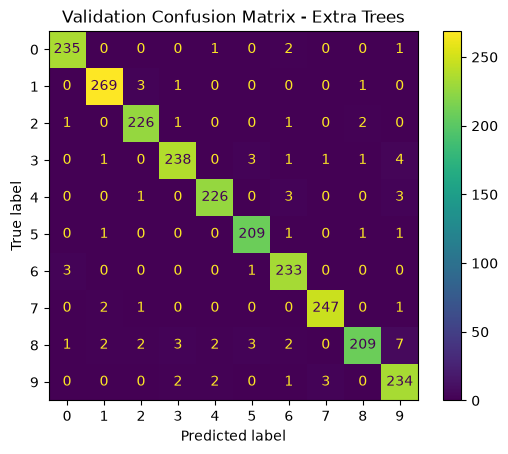

In [45]:
for name, model in models.items():

    y_val_pred = model.predict(X_val)

    cm = confusion_matrix(
        y_val,
        y_val_pred
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm
    )

    disp.plot()
    plt.title(f"Validation Confusion Matrix - {name}")
    plt.show()

In [46]:
best_model_name = max(
    results,
    key=lambda name: results[name]["validation_accuracy"]
)

print(
    "Selected model:",
    best_model_name
)

Selected model: Extra Trees


In [47]:
final_model = models[best_model_name]

In [48]:
start_time = time.time()

X_final, y_final = build_augmented_set(X_train_val, y_train_val, copies=2)
final_model.fit(X_final, y_final)

final_training_time = (
    time.time() - start_time
)

print(
    f"Final training time: "
    f"{final_training_time:.2f} seconds"
)

Final training time: 67.44 seconds


In [49]:
y_test_pred = final_model.predict(X_test)

test_accuracy = accuracy_score(
    y_test,
    y_test_pred
)

print(
    f"Final Test Accuracy: "
    f"{test_accuracy:.4f}"
)

Final Test Accuracy: 0.8345


In [50]:
print(
    classification_report(
        y_test,
        y_test_pred
    )
)

              precision    recall  f1-score   support

           0       0.95      0.93      0.94       399
           1       0.67      0.99      0.80       456
           2       0.95      0.82      0.88       386
           3       0.82      0.80      0.81       415
           4       0.86      0.85      0.86       389
           5       0.89      0.72      0.80       355
           6       0.91      0.89      0.90       394
           7       0.87      0.89      0.88       419
           8       0.89      0.59      0.71       384
           9       0.72      0.82      0.77       403

    accuracy                           0.83      4000
   macro avg       0.85      0.83      0.83      4000
weighted avg       0.85      0.83      0.83      4000



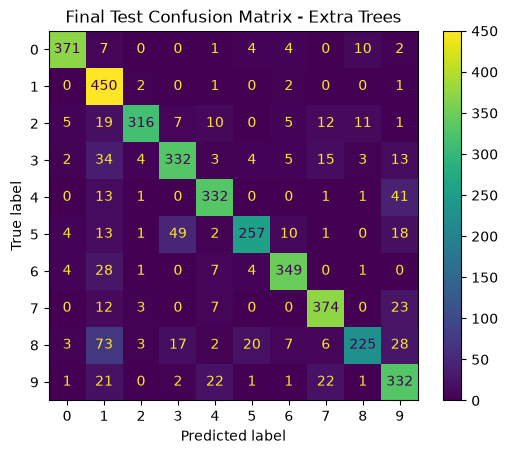

In [51]:
test_cm = confusion_matrix(
    y_test,
    y_test_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=test_cm
)

disp.plot()
plt.title(
    f"Final Test Confusion Matrix - {best_model_name}"
)
plt.show()

## 4. Spara modeller

In [52]:
final_model_path = (
    "artifacts/final_model.joblib"
)

joblib.dump(final_model, final_model_path, compress=3)

print(
    "Final model saved to:",
    final_model_path
)

Final model saved to: artifacts/final_model.joblib


In [53]:
final_test_results = {
    "accuracy": round(
        float(test_accuracy),
        4
    ),

    "classification_report": classification_report(
        y_test,
        y_test_pred,
        output_dict=True
    ),

    "confusion_matrix": test_cm.tolist(),

    "training_time_seconds": round(
        float(final_training_time),
        3
    ),

    "model_file": final_model_path
}

In [54]:
metadata = {

    "project": {
        "name": "MNIST Handwritten Digit Classification",
        "dataset": "MNIST",
        "n_samples": int(len(X)),
        "n_features": int(X.shape[1]),
        "classes": [
            int(i)
            for i in np.unique(y)
        ]
    },

    "data_split": {
        "train_samples": int(len(X_train)),
        "validation_samples": int(len(X_val)),
        "test_samples": int(len(X_test)),

        "train_ratio": round(
            len(X_train) / len(X),
            4
        ),

        "validation_ratio": round(
            len(X_val) / len(X),
            4
        ),

        "test_ratio": round(
            len(X_test) / len(X),
            4
        ),

        "random_state": 42,
        "stratified": True
    },

    "preprocessing": {
        "pixel_normalization": "divide by 255",
        "input_shape": [28, 28],
        "model_input_features": 784
    },

    "models": results,

    "selected_model": {
        "name": best_model_name,

        "validation_accuracy": (
            results[best_model_name][
                "validation_accuracy"
            ]
        )
    },

    "final_test": final_test_results
}

In [55]:
metadata_path = (
    "artifacts/metadata.json"
)

with open(
    metadata_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        metadata,
        f,
        indent=4,
        ensure_ascii=False
    )

print(
    f"Metadata saved to: {metadata_path}"
)

Metadata saved to: artifacts/metadata.json


In [56]:
with open(
    "artifacts/metadata.json",
    "r",
    encoding="utf-8"
) as f:

    loaded_metadata = json.load(f)

print(
    json.dumps(
        loaded_metadata,
        indent=4,
        ensure_ascii=False
    )
)

{
    "project": {
        "name": "MNIST Handwritten Digit Classification",
        "dataset": "MNIST",
        "n_samples": 20000,
        "n_features": 784,
        "classes": [
            0,
            1,
            2,
            3,
            4,
            5,
            6,
            7,
            8,
            9
        ]
    },
    "data_split": {
        "train_samples": 13600,
        "validation_samples": 2400,
        "test_samples": 4000,
        "train_ratio": 0.68,
        "validation_ratio": 0.12,
        "test_ratio": 0.2,
        "random_state": 42,
        "stratified": true
    },
    "preprocessing": {
        "pixel_normalization": "divide by 255",
        "input_shape": [
            28,
            28
        ],
        "model_input_features": 784
    },
    "models": {
        "Extra Trees": {
            "training_time_seconds": 20.562,
            "validation_accuracy": 0.9692,
            "validation_classification_report": {
                "0": {


In [57]:
print(
    "Selected model:",
    loaded_metadata["selected_model"]["name"]
)

print(
    "Final test accuracy:",
    loaded_metadata["final_test"]["accuracy"]
)

Selected model: Extra Trees
Final test accuracy: 0.8345


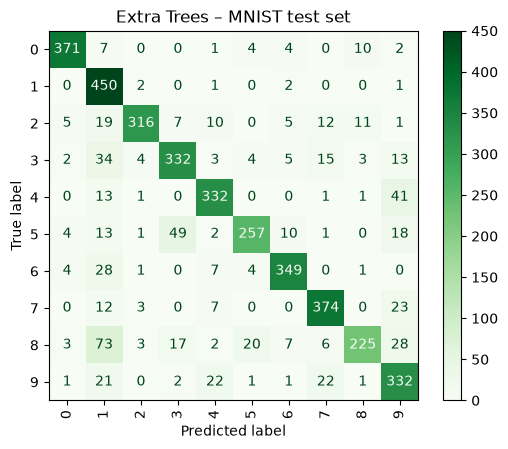

In [58]:
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Greens', xticks_rotation='vertical')
plt.title('Extra Trees – MNIST test set')
plt.show()


## 3. Förbättrad preprocessing för bilder från mobilen

Bilder från mobilen kan ha skuggor, ojämnt ljus, olika upplösning och olika bakgrundsfärg. Funktionen i `preprocessing.py`:

- jämnar ut långsamma ljusvariationer och förstärker kontrasten
- väljer automatiskt om förgrunden är ljus eller mörk
- kombinerar lokal och global tröskling och sluter små avbrott i pennstreck
- väljer en tydlig förgrundskomponent, beskär siffran och behåller proportionerna
- skalar siffran till högst 20×20 pixlar, centrerar den och normaliserar till 0–1

Titta på både trösklingsmasken och den slutliga 28×28-bilden. Om masken inte visar siffran tydligt kommer modellen sannolikt att gissa fel.

In [59]:
from preprocessing import preprocess_phone_digit

## 4. Visualisera preprocessing

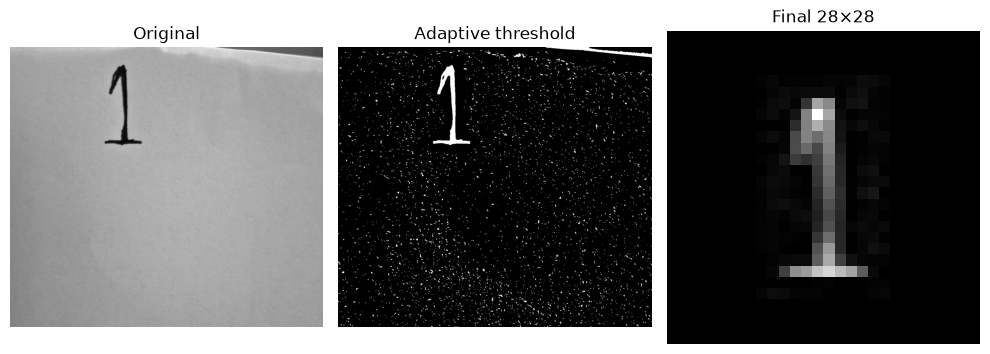

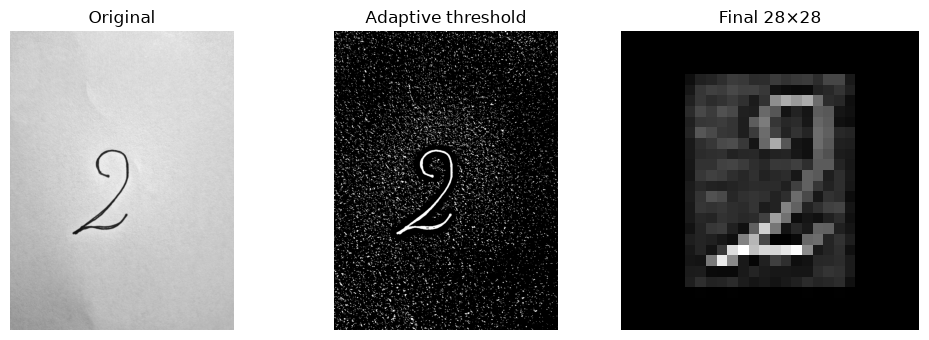

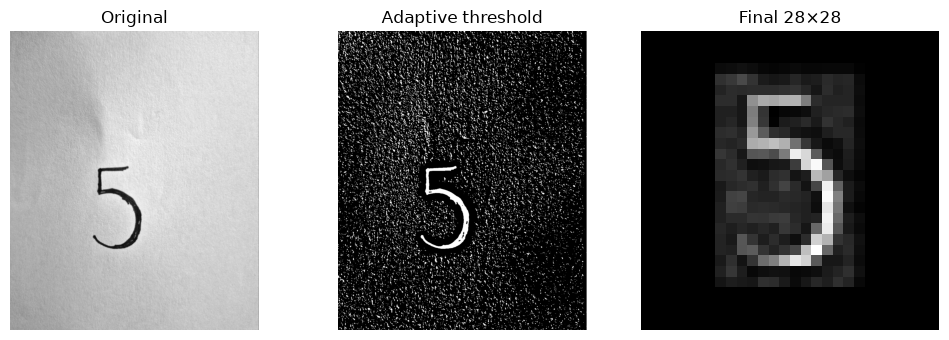

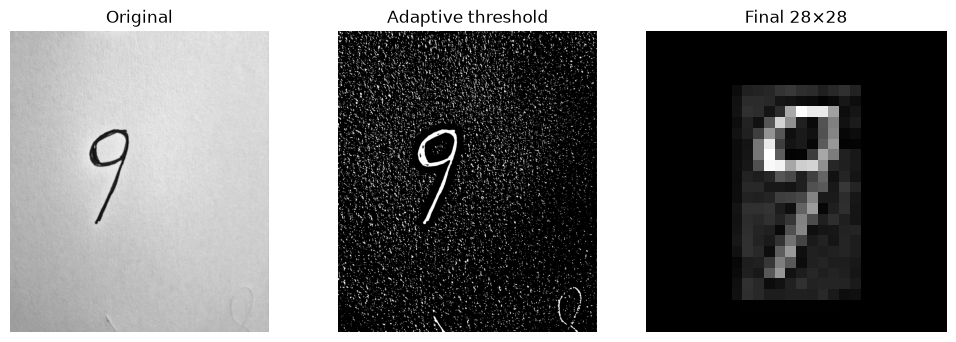

In [60]:
def show_preprocessing(path):
    _, original, threshold, processed = preprocess_phone_digit(
        path,
        return_debug=True
    )

    fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))

    axes[0].imshow(original, cmap="gray")
    axes[0].set_title("Original")
    axes[0].axis("off")

    axes[1].imshow(threshold, cmap="gray")
    axes[1].set_title("Adaptive threshold")
    axes[1].axis("off")

    axes[2].imshow(processed, cmap="gray")
    axes[2].set_title("Final 28×28")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()


for path in [
    "digits_images/digit1.jpg",
    "digits_images/digit2.jpg",
    "digits_images/digit5.jpg",
    "digits_images/digit9.jpg",
]:
    show_preprocessing(path)


## 5. Prediktera egna bilder

In [61]:
def predict_phone_digit(path, model):
    features = preprocess_phone_digit(path)

    probabilities = model.predict_proba(features)[0]
    prediction = int(np.argmax(probabilities))

    return prediction, probabilities


image_paths = [
    "digits_images/digit1.jpg",
    "digits_images/digit2.jpg",
    "digits_images/digit5.jpg",
    "digits_images/digit9.jpg",
]

for path in image_paths:
    prediction, probabilities = predict_phone_digit(path, final_model)

    top3 = np.argsort(probabilities)[::-1][:3]

    print(f"\n{path}")
    print("Prediction:", prediction)
    print(
        "Top 3:",
        [
            (int(i), round(float(probabilities[i]), 3))
            for i in top3
        ]
    )



digits_images/digit1.jpg
Prediction: 1
Top 3: [(1, 0.185), (6, 0.165), (9, 0.135)]

digits_images/digit2.jpg
Prediction: 3
Top 3: [(3, 0.225), (0, 0.125), (4, 0.115)]

digits_images/digit5.jpg
Prediction: 8
Top 3: [(8, 0.19), (3, 0.17), (6, 0.115)]

digits_images/digit9.jpg
Prediction: 8
Top 3: [(8, 0.175), (3, 0.155), (9, 0.135)]


## 6. Spara modellen för Streamlit

Streamlit ska använda exakt samma modell och preprocessing som notebooken.

In [62]:
os.makedirs("artifacts", exist_ok=True)

metadata = {
    "model": "ExtraTreesClassifier",
    "n_estimators": 200,
    "random_state": 42,
    "input_shape": [28, 28],
    "features": 784,
    "normalization": "pixel / 255.0",
    "test_accuracy": float(test_accuracy),
}

with open(
    "artifacts/metadata.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(metadata, f, indent=2)

print("Metadata saved; model is in artifacts/final_model.joblib.")


Metadata saved; model is in artifacts/final_model.joblib.
